In [1]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# Project root = folder containing this notebook
PROJECT_DIR = Path(".").resolve()
DATA_PATH = PROJECT_DIR / "data" / "ml_Metro_Interstate_Traffic_Volume.csv"
ART_DIR = PROJECT_DIR / "artifacts"
ART_DIR.mkdir(exist_ok=True)

print("Project :", PROJECT_DIR)
print("Data    :", DATA_PATH)
print("MLflow  :", mlflow.__version__)

Project : C:\Users\Sadanand\OneDrive\NUS AI and ML Course\00 Capstone Project\capstone_projct_shrikant
Data    : C:\Users\Sadanand\OneDrive\NUS AI and ML Course\00 Capstone Project\capstone_projct_shrikant\data\ml_Metro_Interstate_Traffic_Volume.csv
MLflow  : 3.15.1


In [2]:
TRACKING_URI = f"sqlite:///{(PROJECT_DIR / 'mlflow.db').as_posix()}"
EXPERIMENT_NAME = "traffic_volume_analysis"

mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

<Experiment: artifact_location=('file:C:/Users/Sadanand/OneDrive/NUS AI and ML Course/00 Capstone '
 'Project/capstone_projct_shrikant/mlruns/1'), creation_time=1790516599863, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1790516599863, lifecycle_stage='active', name='traffic_volume_analysis', tags={}, trace_location=None, workspace='default'>

In [3]:
df = pd.read_csv(DATA_PATH)
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,hour,...,weather_main_Fog,weather_main_Haze,weather_main_Mist,weather_main_Rain,weather_main_Smoke,weather_main_Snow,weather_main_Squall,weather_main_Thunderstorm,congestion_category,high_risk
0,No Holiday,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,9,...,0,0,0,0,0,0,0,0,Severe,0
1,No Holiday,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,10,...,0,0,0,0,0,0,0,0,High,0
2,No Holiday,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,11,...,0,0,0,0,0,0,0,0,High,0
3,No Holiday,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,12,...,0,0,0,0,0,0,0,0,Severe,0
4,No Holiday,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,13,...,0,0,0,0,0,0,0,0,High,0


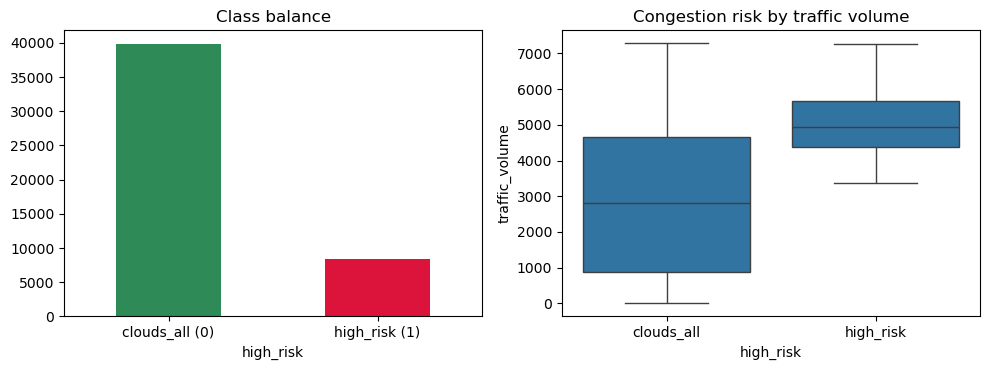

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

df["high_risk"].value_counts().plot(kind="bar", ax=axes[0], color=["seagreen", "crimson"])
axes[0].set_title("Class balance")
axes[0].set_xlabel("high_risk")
axes[0].set_xticklabels(["clouds_all (0)", "high_risk (1)"], rotation=0)

sns.boxplot(data=df, x="high_risk", y="traffic_volume", ax=axes[1])
axes[1].set_title("Congestion risk by traffic volume")
axes[1].set_xticklabels(["clouds_all", "high_risk"])

plt.tight_layout()
plt.show()

In [17]:
TARGET = "high_risk"
ID_COLS = ["traffic_volume", "hour"]

y = df[TARGET]
X = df.drop(columns=ID_COLS + [TARGET])
X = X.drop(columns=['date_time','date_time.1'],errors='ignore')

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42, stratify=y
)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Categorical columns:", cat_cols)
print("Numeric columns    :", len(num_cols))

Train: (24093, 43) | Test: (24094, 43)
Categorical columns: ['holiday', 'weather_main', 'weather_description', 'traffic_category', 'holiday.1', 'weather_description.1', 'traffic_category.1', 'congestion_category']
Numeric columns    : 35


In [18]:
def evaluate(model, X_te, y_te):
    proba = model.predict_proba(X_te)[:, 1]
    pred = (proba >= 0.5).astype(int)
    metrics = {
        "accuracy": float(accuracy_score(y_te, pred)),
        "precision": float(precision_score(y_te, pred, zero_division=0)),
        "recall": float(recall_score(y_te, pred, zero_division=0)),
        "f1": float(f1_score(y_te, pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_te, proba)),
    }
    return metrics, pred


def save_confusion(y_true, y_pred, path, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4.2, 3.6))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"],
    )
    plt.title(title)
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.savefig(path, dpi=120)
    plt.close()


def log_run_files(run_name, y_true, y_pred):
    cm_path = ART_DIR / f"{run_name}_cm.png"
    save_confusion(y_true, y_pred, cm_path, f"Confusion — {run_name}")
    mlflow.log_artifact(str(cm_path))

    report_path = ART_DIR / f"{run_name}_report.txt"
    report_path.write_text(
        classification_report(y_true, y_pred, target_names=["Legit", "Fraud"]),
        encoding="utf-8",
    )
    mlflow.log_artifact(str(report_path))

In [19]:

rf_grid = [
    {"n_estimators": 10,  "max_depth": 5,  "min_samples_leaf": 5, "class_weight": "balanced"},
    {"n_estimators":20, "max_depth": 8,  "min_samples_leaf": 5, "class_weight": "balanced"},
  #  {"n_estimators": 50, "max_depth": 10, "min_samples_leaf": 5, "class_weight": "balanced"},
   # {"n_estimators": 80, "max_depth": 12, "min_samples_leaf": 5, "class_weight": "balanced_subsample"},
]
if hasattr(X_train, "dtypes"):
    
    float_cols = X_train.select_dtypes(include=['float64']).columns
    X_train[float_cols] = X_train[float_cols].astype(np.float32)
    X_test[float_cols] = X_test[float_cols].astype(np.float32)
elif isinstance(X_train, np.ndarray) and X_train.dtype == np.float64:
    
    X_train = X_train.astype(np.float32)
    X_test = X_test.astype(np.float32)

rf_results = []

for i, params in enumerate(rf_grid, 1):
    run_name = f"rf_nest{params['n_estimators']}_depth{params['max_depth']}_leaf{params['min_samples_leaf']}"

    with mlflow.start_run(run_name=run_name):
        mlflow.set_tags({
            "model_family": "RandomForest",
            "use_case": "traffic congestion",
            "stage": "hyperparameter_tuning",
        })
        mlflow.log_params({f"rf_{k}": v for k, v in params.items()})
        mlflow.log_param("model_type", "RandomForestClassifier")

        pipe = Pipeline([
            ("prep", preprocess),
            ("model", RandomForestClassifier(random_state=42, n_jobs=2, max_samples=0.5,max_features='sqrt', **params)),
        ])
        pipe.fit(X_train, y_train)

        metrics, pred = evaluate(pipe, X_test, y_test)
        mlflow.log_metrics(metrics)
        log_run_files(run_name, y_test, pred)
        mlflow.sklearn.log_model(pipe, name="model", serialization_format="cloudpickle")

        print(f"[{i}/{len(rf_grid)}] {run_name} | F1={metrics['f1']:.3f} | AUC={metrics['roc_auc']:.3f}")
        rf_results.append({"run": run_name, **params, **metrics})

pd.DataFrame(rf_results).sort_values("f1", ascending=False)

2026/09/27 23:09:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[1/2] rf_nest10_depth5_leaf5 | F1=0.956 | AUC=1.000


2026/09/27 23:13:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[2/2] rf_nest20_depth8_leaf5 | F1=0.997 | AUC=1.000


,run,n_estimators,max_depth,min_samples_leaf,class_weight,accuracy,precision,recall,f1,roc_auc
1,rf_nest20_depth8_leaf5,20,8,5,balanced,0.999004,0.994279,1.0,0.997131,0.999999
0,rf_nest10_depth5_leaf5,10,5,5,balanced,0.984062,0.915697,1.0,0.955994,0.999974


In [20]:
neg = int((y_train == 0).sum())
pos = int((y_train == 1).sum())
scale_pos_weight = neg / max(pos, 1)
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

xgb_grid = [
    {"n_estimators": 80,  "max_depth": 3, "learning_rate": 0.10, "subsample": 0.80, "colsample_bytree": 0.80},
    {"n_estimators": 120, "max_depth": 4, "learning_rate": 0.08, "subsample": 0.90, "colsample_bytree": 0.80},
  #  {"n_estimators": 150, "max_depth": 5, "learning_rate": 0.05, "subsample": 0.85, "colsample_bytree": 0.90},
  #  {"n_estimators": 200, "max_depth": 6, "learning_rate": 0.05, "subsample": 1.00, "colsample_bytree": 1.00},
]

xgb_results = []

for i, params in enumerate(xgb_grid, 1):
    run_name = f"xgb_nest{params['n_estimators']}_depth{params['max_depth']}_lr{params['learning_rate']}"

    with mlflow.start_run(run_name=run_name):
        mlflow.set_tags({
            "model_family": "XGBoost",
            "use_case": "fraud_detection",
            "stage": "hyperparameter_tuning",
        })
        mlflow.log_params({f"xgb_{k}": v for k, v in params.items()})
        mlflow.log_param("model_type", "XGBClassifier")
        mlflow.log_param("scale_pos_weight", round(scale_pos_weight, 3))

        model = XGBClassifier(
            objective="binary:logistic",
            eval_metric="auc",
            random_state=42,
            n_jobs=-1,
            scale_pos_weight=scale_pos_weight,
            **params,
        )
        pipe = Pipeline([
            ("prep", preprocess),
            ("model", model),
        ])
        pipe.fit(X_train, y_train)

        metrics, pred = evaluate(pipe, X_test, y_test)
        mlflow.log_metrics(metrics)
        log_run_files(run_name, y_test, pred)
        mlflow.sklearn.log_model(pipe, name="model", serialization_format="cloudpickle")

        print(f"[{i}/{len(xgb_grid)}] {run_name} | F1={metrics['f1']:.3f} | AUC={metrics['roc_auc']:.3f}")
        xgb_results.append({"run": run_name, **params, **metrics})

pd.DataFrame(xgb_results).sort_values("f1", ascending=False)

scale_pos_weight = 4.78


2026/09/27 23:15:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[1/2] xgb_nest80_depth3_lr0.1 | F1=0.999 | AUC=1.000


2026/09/27 23:15:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[2/2] xgb_nest120_depth4_lr0.08 | F1=0.999 | AUC=1.000


,run,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,accuracy,precision,recall,f1,roc_auc
0,xgb_nest80_depth3_lr0.1,80,3,0.10,0.8,0.8,0.999751,0.998564,1.0,0.999281,0.999918
1,xgb_nest120_depth4_lr0.08,120,4,0.08,0.9,0.8,0.999751,0.998564,1.0,0.999281,0.999998


      family                       run  accuracy  precision  recall       f1  roc_auc
     XGBoost   xgb_nest80_depth3_lr0.1  0.999751   0.998564     1.0 0.999281 0.999918
     XGBoost xgb_nest120_depth4_lr0.08  0.999751   0.998564     1.0 0.999281 0.999998
RandomForest    rf_nest20_depth8_leaf5  0.999004   0.994279     1.0 0.997131 0.999999
RandomForest    rf_nest10_depth5_leaf5  0.984062   0.915697     1.0 0.955994 0.999974


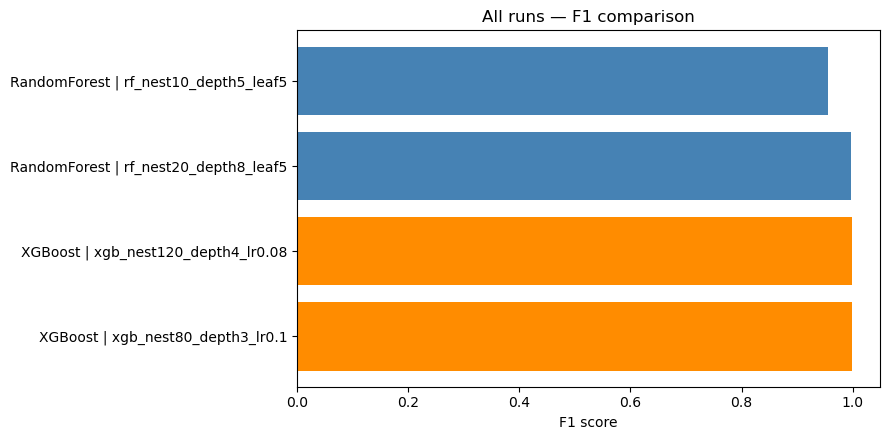


Best run: XGBoost | xgb_nest80_depth3_lr0.1 | F1 = 0.999
Summary logged to MLflow.
Local files in: C:\Users\Sadanand\OneDrive\NUS AI and ML Course\00 Capstone Project\capstone_projct_shrikant\artifacts


In [21]:
summary = pd.concat([
    pd.DataFrame(rf_results).assign(family="RandomForest"),
    pd.DataFrame(xgb_results).assign(family="XGBoost"),
], ignore_index=True).sort_values("f1", ascending=False)

summary_path = ART_DIR / "tuning_summary.csv"
summary.to_csv(summary_path, index=False)
print(summary[["family", "run", "accuracy", "precision", "recall", "f1", "roc_auc"]].to_string(index=False))

plt.figure(figsize=(9, 4.5))
labels = summary["family"] + " | " + summary["run"].str.slice(0, 28)
colors = ["steelblue" if f == "RandomForest" else "darkorange" for f in summary["family"]]
plt.barh(labels, summary["f1"], color=colors)
plt.xlabel("F1 score")
plt.title("All runs — F1 comparison")
plt.tight_layout()
chart_path = ART_DIR / "f1_comparison.png"
plt.savefig(chart_path, dpi=130)
plt.show()

best = summary.iloc[0]
print("\nBest run:", best["family"], "|", best["run"], "| F1 =", round(best["f1"], 3))

with mlflow.start_run(run_name="tuning_summary"):
    mlflow.set_tags({
        "model_family": "Summary",
        "use_case": "fraud_detection",
        "stage": "comparison",
    })
    mlflow.log_param("best_run", best["run"])
    mlflow.log_param("best_family", best["family"])
    mlflow.log_metrics({
        "best_f1": float(best["f1"]),
        "best_roc_auc": float(best["roc_auc"]),
        "best_precision": float(best["precision"]),
        "best_recall": float(best["recall"]),
        "n_rf_runs": len(rf_results),
        "n_xgb_runs": len(xgb_results),
    })
    mlflow.log_artifact(str(summary_path))
    mlflow.log_artifact(str(chart_path))
    mlflow.log_artifact(str(DATA_PATH))

print("Summary logged to MLflow.")
print("Local files in:", ART_DIR)